<a href="https://colab.research.google.com/github/sagar-kc7/LangGraph/blob/main/LangGraph_02_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Conditional Graph

In [2]:
from typing import TypedDict

In [3]:
from langgraph.graph import StateGraph, START, END

In [5]:
class AgentState(TypedDict):
  number1: int
  operation: str
  number2: int
  finalnumber: int

In [7]:
def adder(state:AgentState) -> AgentState:
  """This node adds thee 2 numbers"""
  state["finalnumber"] = state["number1"] + state["number2"]
  return state

def subtractor(state:AgentState) -> AgentState:
  """This node subtracts the 2 numbers"""
  state["finalnumber"] = state["number1"] - state["number2"]
  return state

def multiplier(state:AgentState) -> AgentState:
  """This node multiplies the 2 numbers"""
  state["finalnumber"] = state["number1"] * state["number2"]
  return state

def decide_next_node(state:AgentState) -> AgentState:
  """This node will decide which node to go to next"""
  if state["operation"] == "+":
    return "addition_operation"
  elif state["operation"] == "-":
    return "subtraction_operation"
  elif state["operation"] == "*":
    return "multiplication_operation"
  else:
    pass

In [9]:
graph = StateGraph(AgentState)

graph.add_node("add_node", adder)
graph.add_node("sub_node", subtractor)
graph.add_node("mul_node", multiplier)
graph.add_node("router", lambda state:state)

graph.add_edge(START, "router")

graph.add_conditional_edges(
    "router",
    decide_next_node,
    {
        "addition_operation": "add_node",
        "subtraction_operation": "sub_node",
        "multiplication_operation": "mul_node",
    }

)

graph.add_edge("add_node", END)
graph.add_edge("sub_node", END)
graph.add_edge("mul_node", END)

app = graph.compile()

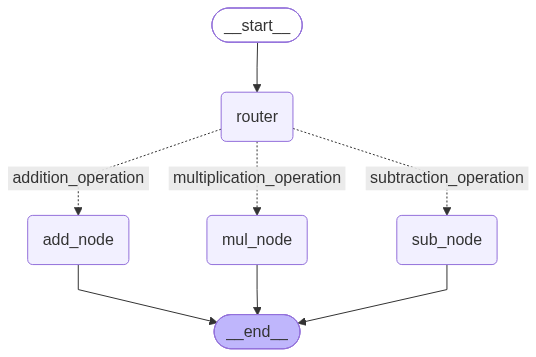

In [11]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [13]:
initial_state_1 = AgentState(number1 = 10, number2 = 20, operation = "*")
print(app.invoke(initial_state_1))

{'number1': 10, 'operation': '*', 'number2': 20, 'finalnumber': 200}
